Q7 VQ-VAE training, inference and accuracy

In [1]:
model_name = 'VQ_VAE-EMA_res'
import os
import tqdm
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets
from torch.utils.data import DataLoader,TensorDataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from torchvision.utils import save_image,make_grid
from torch.utils.data import DataLoader, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:

image_size = 128
batch_size = 32
latent_dim = 128
embedding_dim=128
num_embeddings=512
commitment_cost=0.1

MEAN = torch.tensor([0.47998455, 0.46537864, 0.33653912])
STD = torch.tensor([0.22608626, 0.22103393, 0.21348171])

# Define transformations
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Load the dataset
data_path = os.path.join(os.getcwd(), 'data', 'butterfly_new')
dataset = ImageFolder(root=data_path, transform=transform)
data_loader=DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=8)
# Define the split sizes
train_size = int(0.8 * len(dataset))  # 80% for training
test_size = len(dataset) - train_size  # 20% for testing

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

In [4]:
class ResidualLayer(nn.Module):
    def __init__(self, res_h_dim):
        super(ResidualLayer, self).__init__()
        self.block = nn.Sequential(
            nn.ReLU(),
            nn.Conv2d(res_h_dim, res_h_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(res_h_dim, res_h_dim, kernel_size=1)
        )

    def forward(self, x):
        return x + self.block(x)  # Residual connection


class ResidualStack(nn.Module):
    def __init__(self, res_h_dim, n_res_layers):
        super(ResidualStack, self).__init__()
        self.residual_layers = nn.ModuleList([ResidualLayer(res_h_dim) for _ in range(n_res_layers)])

    def forward(self, x):
        for layer in self.residual_layers:
            x = layer(x)
        return x

class Encoder(nn.Module):
    def __init__(self, in_channels, h_dim, res_h_dim, n_res_layers):
        super(Encoder, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, h_dim // 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(h_dim // 2, h_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(h_dim, res_h_dim, kernel_size=4, stride=2, padding=1)
        )
        self.residual_stack = ResidualStack(res_h_dim, n_res_layers)

    def forward(self, x):
        x = self.initial(x)
        x = self.residual_stack(x)
        return x


class Decoder(nn.Module):
    def __init__(self, out_channels, h_dim, res_h_dim, n_res_layers):
        super(Decoder, self).__init__()
        self.residual_stack = ResidualStack(res_h_dim, n_res_layers)
        self.initial = nn.Sequential(
            nn.ConvTranspose2d(res_h_dim, h_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(h_dim, h_dim // 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(h_dim // 2, out_channels, kernel_size=4, stride=2, padding=1)
        )

    def forward(self, x):
        x = self.residual_stack(x)
        x = self.initial(x)
        return x
    
class VectorQuantizerEMA(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost=0.25, decay=0.99, epsilon=1e-5):
        super(VectorQuantizerEMA, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.epsilon = epsilon

        # Initialize embeddings
        self.embeddings = nn.Parameter(torch.randn(num_embeddings, embedding_dim))
        self.register_buffer("ema_cluster_size", torch.zeros(num_embeddings))
        self.register_buffer("ema_embedding_avg", torch.randn(num_embeddings, embedding_dim))

    def forward(self, x):
        # Flatten input to (batch_size * num_latents, embedding_dim)
        flat_x = x.view(-1, self.embedding_dim)

        # Compute distances between encoder outputs and embeddings
        distances = (
            torch.sum(flat_x ** 2, dim=1, keepdim=True)
            + torch.sum(self.embeddings ** 2, dim=1)
            - 2 * torch.matmul(flat_x, self.embeddings.t())
        )

        # Find nearest embedding index for each latent vector
        encoding_indices = torch.argmin(distances, dim=1)
        quantized = self.embeddings[encoding_indices].view(x.shape)

        # Compute commitment loss
        e_latent_loss = torch.mean((quantized.detach() - x) ** 2)
        loss = self.commitment_cost * e_latent_loss

        # EMA updates for the embeddings
        if self.training:
            # One-hot encode indices
            encodings = torch.zeros(encoding_indices.size(0), self.num_embeddings, device=x.device)
            encodings.scatter_(1, encoding_indices.unsqueeze(1), 1)

            # Update cluster size using EMA
            ema_cluster_size = self.ema_cluster_size * self.decay + (1 - self.decay) * encodings.sum(0)
            # Laplace smoothing to avoid division by zero
            n = torch.sum(ema_cluster_size) + self.epsilon
            self.ema_cluster_size = ema_cluster_size / n * n  # Normalized by overall cluster size

            # Update embedding averages using EMA
            embedding_sum = torch.matmul(encodings.t(), flat_x)
            self.ema_embedding_avg = self.ema_embedding_avg * self.decay + (1 - self.decay) * embedding_sum

            # Normalize embedding averages to get updated codebook
            self.embeddings.data = self.ema_embedding_avg / (self.ema_cluster_size.unsqueeze(1) + self.epsilon)

        # Detach gradients from quantized output for backprop
        quantized = x + (quantized - x).detach()

        return quantized, loss

class VQVAE(nn.Module):
    def __init__(self, in_channels, out_channels, h_dim, res_h_dim, n_res_layers, num_embeddings):
        super(VQVAE, self).__init__()
        self.encoder = Encoder(in_channels, h_dim, res_h_dim, n_res_layers)
        self.decoder = Decoder(out_channels, h_dim, res_h_dim, n_res_layers)
        self.vector_quantizer = VectorQuantizerEMA(num_embeddings, res_h_dim)  # Using EMA-based quantizer

    def forward(self, x):
        encoded = self.encoder(x)
        quantized, vq_loss = self.vector_quantizer(encoded)
        decoded = self.decoder(quantized)
        return decoded, vq_loss


# Function to save a grid of generated images
def save_generated_images(model, epoch, dataloader, device, output_dir):
    model.eval()
    with torch.no_grad():
        images, _ = next(iter(dataloader))
        images = images[:100].to(device)  # Get a batch of 100 images
        recon_images, _ = model(images)   # Reconstruct images using VQ-VAE

        # Create and save a grid of 10x10 generated images
        grid = make_grid(recon_images, nrow=10, normalize=True)
        save_image(grid, f"{output_dir}/generated_epoch_{epoch+1}.png")
        print(f"Saved generated images for epoch {epoch+1} to {output_dir}")

In [5]:

import torch.optim as optim
from torchvision.utils import save_image, make_grid

# Directory to save generated images
output_dir = "vqvae_generated_images"
os.makedirs(output_dir, exist_ok=True)

# Training loop
def train_vqvae(model, dataloader, epochs, lr, device):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss, recon_loss, vq_loss = 0, 0, 0

        for images, _ in dataloader:
            images = images.to(device)
            optimizer.zero_grad()

            # Forward pass
            recon_images, vq_loss_value = model(images)
            recon_loss_value = criterion(recon_images, images)  # Reconstruction loss
            loss = recon_loss_value + vq_loss_value  # Total loss
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Accumulate losses
            total_loss += loss.item()
            recon_loss += recon_loss_value.item()
            vq_loss += vq_loss_value.item()

        # Print epoch losses
        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Total Loss: {total_loss:.4f}, "
            f"Recon Loss: {recon_loss:.4f}, "
            f"VQ Loss: {vq_loss:.4f}"
        )

        # Save generated images for the current epoch
        save_generated_images(model, epoch, dataloader, device, output_dir)



In [5]:
# Set hyperparameters for model
in_channels = 3
out_channels = 3
h_dim = 128
res_h_dim = 64
n_res_layers = 3
num_embeddings = 512

# Initialize VQ-VAE model with specified parameters
vqvae = VQVAE(
    in_channels=in_channels,
    out_channels=out_channels,
    h_dim=h_dim,
    res_h_dim=res_h_dim,
    n_res_layers=n_res_layers,
    num_embeddings=num_embeddings
).to(device)

# Train the VQ-VAE model
train_vqvae(vqvae, data_loader, epochs=50, lr=1e-4, device=device)
vqvae = torch.save(vqvae, model_name+'.pth')


Epoch [1/50], Total Loss: 86.8617, Recon Loss: 73.9576, VQ Loss: 12.9041
Saved generated images for epoch 1 to vqvae_generated_images
Epoch [2/50], Total Loss: 87.5255, Recon Loss: 60.6999, VQ Loss: 26.8256
Saved generated images for epoch 2 to vqvae_generated_images
Epoch [3/50], Total Loss: 87.1684, Recon Loss: 57.6400, VQ Loss: 29.5284
Saved generated images for epoch 3 to vqvae_generated_images
Epoch [4/50], Total Loss: 88.9827, Recon Loss: 54.6125, VQ Loss: 34.3702
Saved generated images for epoch 4 to vqvae_generated_images
Epoch [5/50], Total Loss: 92.7613, Recon Loss: 52.7555, VQ Loss: 40.0058
Saved generated images for epoch 5 to vqvae_generated_images
Epoch [6/50], Total Loss: 98.0236, Recon Loss: 51.2096, VQ Loss: 46.8140
Saved generated images for epoch 6 to vqvae_generated_images
Epoch [7/50], Total Loss: 100.1457, Recon Loss: 50.7400, VQ Loss: 49.4057
Saved generated images for epoch 7 to vqvae_generated_images
Epoch [8/50], Total Loss: 102.3270, Recon Loss: 50.4697, VQ L

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 16.00 GiB of which 0 bytes is free. Of the allocated memory 24.55 GiB is allocated by PyTorch, and 5.83 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [6]:
vqvae = torch.save(vqvae, model_name+'.pth')

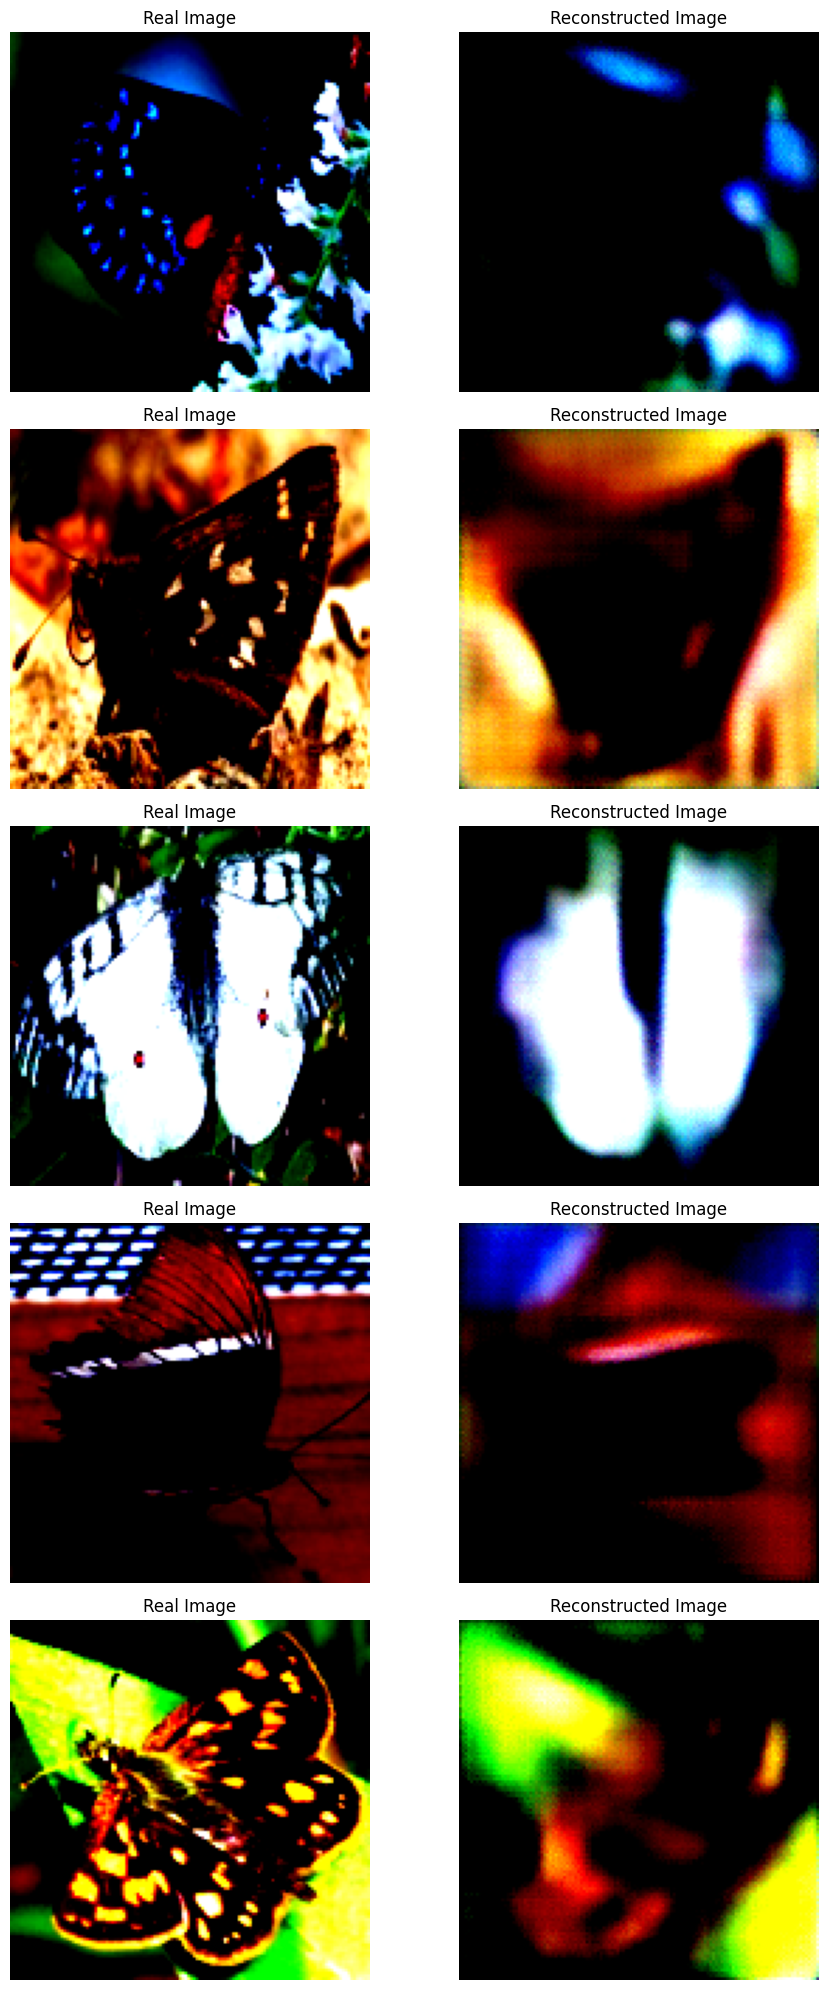

In [22]:
# Give real images to encoder and get reconstructed images from decoder
# Plot the real and reconstructed images
def plot_reconstructed_images(model, dataloader, device, n_images=5):
    model.eval()
    images, _ = next(iter(dataloader))
    images = images[:n_images].to(device)
    with torch.no_grad():
        recon_images, _ = model(images)

    images = images.cpu()
    recon_images = recon_images.cpu()
    images = torch.clamp(images, 0, 1)
    recon_images = torch.clamp(recon_images, 0, 1)

    fig, axes = plt.subplots(n_images, 2, figsize=(10, 20))
    for i in range(n_images):
        axes[i, 0].imshow(images[i].permute(1, 2, 0))
        axes[i, 0].set_title("Real Image")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(recon_images[i].permute(1, 2, 0))
        axes[i, 1].set_title("Reconstructed Image")
        axes[i, 1].axis('off')
    plt.tight_layout()
    plt.show()

# Load the trained VQ-VAE model
vqvae = torch.load(model_name+'.pth',weights_only=False)
# Plot real and reconstructed images
plot_reconstructed_images(vqvae, test_loader, device, n_images=5)



Generated Images


C:\Users\Shivam\AppData\Local\Temp\ipykernel_17876\4080685522.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vqvae = torch.load(model_name+'.pth')


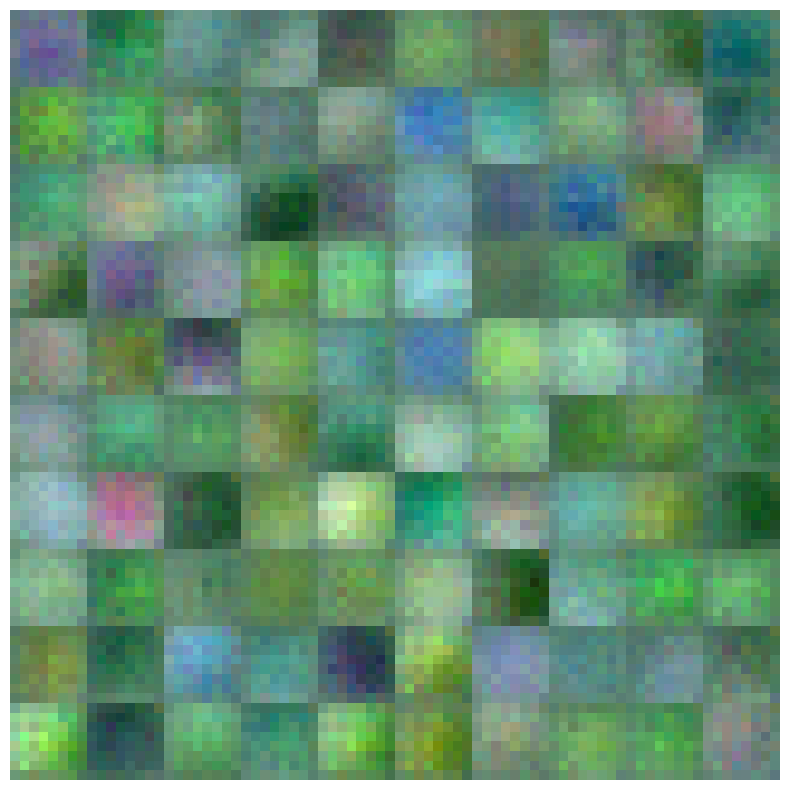

<Figure size 640x480 with 0 Axes>

In [14]:
vqvae = torch.load(model_name+'.pth')
vqvae.eval()

# Function to generate images from random latent vectors
def generate_images(model, n_images, device):
    with torch.no_grad():
        # Generate random latent vectors
        latent = torch.randn(n_images, 64, 1, 1).to(device)
        generated_images = model.decoder(latent)
        return generated_images  # Return the generated images

# Generate images using the trained VQ-VAE model
n_images = 100
generated_images = generate_images(vqvae, n_images, device)
grid = make_grid(generated_images, nrow=10, normalize=True,padding=0)
#plot_image(grid)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.show()
plt.savefig('generated_images.png')

In [20]:
#Posterior inferencing
import torch
import numpy as np



# Perform posterior inference on all images
def posterior_inference(model, dataloader, device="cuda"):
    all_latents = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            # Encode images and quantize them to get latent representations
            encoded = model.encoder(images)
            quantized, _ = model.vector_quantizer(encoded)  # Quantized latent embeddings
            print(quantized.shape)
            # Flatten and store the latent representations
            all_latents.append(quantized.view(quantized.size(0), -1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())  # Store corresponding labels if available

    # Concatenate all latents for the full dataset
    all_latents = np.concatenate(all_latents, axis=0)
    all_labels = np.array(all_labels)

    return all_latents, all_labels

# Load the model and perform inference
# Assuming your model architecture is already defined as `vqvae`
# vqvae = VQVAE(in_channels=3, out_channels=3, h_dim=128, res_h_dim=64, n_res_layers=3, num_embeddings=512)

# Load model from the saved checkpoint
vqvae = torch.load(model_name+'.pth').to(device)
vqvae.eval()

# Perform posterior inference
all_latents, all_labels = posterior_inference(vqvae, data_loader, device="cuda")
# Save or process `all_latents` as needed
np.save("latent_representations.npy", all_latents)
np.save("labels.npy", all_labels)

C:\Users\USER\AppData\Local\Temp\ipykernel_15976\2859954859.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vqvae = torch.load(model_name+'.pth').to(device)


torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32, 64, 16, 16])
torch.Size([32

In [13]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLPClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)


In [14]:
# Load latent vectors and labels (assuming you've already saved them)
latent_vectors = np.load("latent_representations.npy")
labels = np.load("labels.npy")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(latent_vectors, labels, test_size=0.2, random_state=42)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create PyTorch datasets and data loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [19]:
def train_classifier(model, train_loader, criterion, optimizer, device="cuda"):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def evaluate_classifier(model, test_loader, device="cuda"):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    return accuracy

# Model parameters
input_dim = X_train.shape[1]  # Dimension of the latent vectors
hidden_dim = 128  # Hidden layer size (can be adjusted)
output_dim = len(np.unique(labels))  # Number of classes

# Initialize model, loss, and optimizer
classifier = MLPClassifier(input_dim, hidden_dim, output_dim).to("cuda")
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.parameters(), lr=0.001)

# Training loop
epochs = 20
for epoch in range(epochs):
    train_classifier(classifier, train_loader, criterion, optimizer, device="cuda")
    accuracy = evaluate_classifier(classifier, test_loader, device="cuda")
    print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {accuracy:.4f}")


Epoch [1/20], Accuracy: 0.0702
Epoch [2/20], Accuracy: 0.0817
Epoch [3/20], Accuracy: 0.1438
Epoch [4/20], Accuracy: 0.1404
Epoch [5/20], Accuracy: 0.1646
Epoch [6/20], Accuracy: 0.1554
Epoch [7/20], Accuracy: 0.1910
Epoch [8/20], Accuracy: 0.2140
Epoch [9/20], Accuracy: 0.2198
Epoch [10/20], Accuracy: 0.2313
Epoch [11/20], Accuracy: 0.2371
Epoch [12/20], Accuracy: 0.2348
Epoch [13/20], Accuracy: 0.2301
Epoch [14/20], Accuracy: 0.2589
Epoch [15/20], Accuracy: 0.2819
Epoch [16/20], Accuracy: 0.2693
Epoch [17/20], Accuracy: 0.3038
Epoch [18/20], Accuracy: 0.2773
Epoch [19/20], Accuracy: 0.2877
Epoch [20/20], Accuracy: 0.2900


Experiments, results, and observations:

1. VQ-VAE without any residual layer and residual stack, uniform initialization of codebook vectors: 
In this case the codbook and commitment loss combined(termed as vq_loss) was 100 times the reconstruction loss. During training, the reconstructed images were only showing the boarder of the butterflies and failed to reconstruct the colours of the butterflies.

2. VQ-VAE without residual layer, without residual stack and with Exponential Moving Average update for codebook vectors:
 In this case, the reconstruction loss and the vq_loss were of the same order of magnitude, but still the reconstruction was very bad.

3. VQ_VAE with residual layer, residual stack and exponential moving average for codebook vectors: 
This gave the best results but lead to memory error. With the hyperparameters, h_dim=128, res_h_dim=64, num_embedding=512, batch_size=32, which were halved to get rid of the memory error. Still in this case, after 28 epochs, we faced memory error and had to use the path file of the this model to do posterior inferencing and to calculate the accuracy of classification by a neural network.

Using model 3 mentioned above, we did posterior inferencing and got a classification accuracy of 29% by using an MLP based classifier on the generated latent vectors.

With more memory, we could have trained it for more number of epochs, then model 3 would have given much better results.